In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import snapatac2 as snap
import pickle
import sys
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import os
import glob

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['pdf.fonttype'] = 42

### 6b obs/pred scatter

In [2]:
fold_dirs = [f.path for f in os.scandir('/data1/normantm/eli/T7/202511_RPE1_dg50/models/genelevel_clustered/folds_ln') if f.name.startswith('fold')]
test_dfs = [pd.read_csv(os.path.join(fold_dir, 'test_preds.csv'), index_col = 0) for fold_dir in fold_dirs if os.path.exists(os.path.join(fold_dir, 'test_preds.csv'))]
test_preds = pd.concat(test_dfs, axis = 0)
test_preds['is_single'] = test_preds.guide_target.map(lambda g: g.split("_")[0] == g.split("_")[1])
program_features = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv")
test_preds['is_prgm'] = test_preds.gene.isin(program_features.feature.unique())

test_preds.query("not is_single").filter(like = 'resid').corr()

,resid,pred_resid,peak_ablated_pred_resid,expr_ablated_pred_resid,chromvar_ablated_pred_resid
resid,1.000000,0.484251,0.443481,0.089497,0.065157
pred_resid,0.484251,1.000000,0.896620,0.191742,0.162867
peak_ablated_pred_resid,0.443481,0.896620,1.000000,0.168287,0.123080
expr_ablated_pred_resid,0.089497,0.191742,0.168287,1.000000,0.034224
chromvar_ablated_pred_resid,0.065157,0.162867,0.123080,0.034224,1.000000


In [3]:
from scipy.stats import spearmanr
from sklearn.metrics import r2_score, mean_squared_error

test_doubles = test_preds.query("not is_single")
print(np.corrcoef(test_doubles.resid, test_doubles.pred_resid)[0,1])
print(spearmanr(test_doubles.resid, test_doubles.pred_resid)[0])
print(r2_score(test_doubles.resid, test_doubles.pred_resid))
print(np.sqrt(mean_squared_error(test_doubles.resid, test_doubles.pred_resid)))

0.48425067281785816
0.41121971392029977
0.23209757574787582
1.0666945201640001


0.49280207955044975


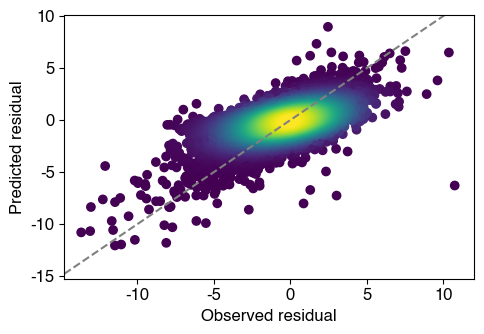

In [4]:
from scipy.stats import gaussian_kde
import numpy as np
import matplotlib.pyplot as plt

df_plot = test_preds.sample(frac=0.01, random_state=42)

x = df_plot.resid.values
y = df_plot.pred_resid.values

xy = np.vstack([x, y])
z = gaussian_kde(xy, bw_method = 2.0)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]

print(np.corrcoef(x, y)[0,1])

plt.figure(figsize=(5,3.5))
plt.scatter(x, y, c=z)
plt.axline((0, 0), slope=1, color='grey', linestyle='--')
plt.xlabel("Observed residual")
plt.ylabel("Predicted residual")
plt.xlim(-14.75,12)
plt.tight_layout()
# plt.savefig("plots/6b_residual_scatter.png", dpi = 300)
plt.show()

### 6c violins

In [9]:
np.random.seed(42)

df_genes = (
    test_preds.query("not is_single")
    .groupby("gene")
    .apply(lambda g: np.corrcoef(g.resid, g.pred_resid)[0, 1])
    .to_frame("corr")
)
df_genes["is_prgm"] = df_genes.index.isin(program_features.feature.unique())

df_plot = df_genes.copy()
df_genes["category"] = "All\ngenes"
df_prgm = df_genes.query("is_prgm").copy()
df_prgm["category"] = "Program\ngenes"
df_plot = pd.concat([df_genes, df_prgm], axis=0)


resid = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260506_tvals_expectation_fit.csv", index_col=0)
pred_mtx = test_preds.query("not is_single").pivot(index="guide_target", columns="gene", values="pred_resid")
valid_genes = resid.columns.intersection(pred_mtx.columns)
programs_diff = pd.read_csv("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/260414_gex_raw_100_prgm_features.csv", index_col=0).query("feature.isin(@valid_genes)")
programs_diff["weight"] = programs_diff.groupby("program_id").weight.transform(lambda x: x / x.sum())

N_PROGRAMS = 100
real_genes = {
    i: programs_diff.query("program_id == @i").feature.tolist()
    for i in range(N_PROGRAMS)
}

real_weights = {
    i: programs_diff.query("program_id == @i").set_index("feature").weight
    for i in range(N_PROGRAMS)
}

rand_genes = {
    i: np.random.choice(valid_genes, size=len(real_genes[i]), replace=False).tolist()
    for i in range(N_PROGRAMS)
}

rand_weights = {
    i: pd.Series(real_weights[i].values, index=rand_genes[i])
    for i in range(N_PROGRAMS)
}


def weighted_program_scores(mtx, genes_by_program, weights_by_program):
    cols = []
    for i in range(N_PROGRAMS):
        genes = genes_by_program[i]
        sub = mtx.filter(items=genes)
        w = weights_by_program[i].loc[sub.columns]
        w = w / w.sum()
        cols.append(sub.mul(w).sum(axis=1).sort_values(ascending=False))
    
    return pd.concat(cols, axis=1).sort_index()

program_residuals = weighted_program_scores(resid, real_genes, real_weights)
pred_prgm_residuals = weighted_program_scores(pred_mtx, real_genes, real_weights)
df_real = pred_prgm_residuals.corrwith(program_residuals, axis=0).to_frame("corr")
df_real["category"] = "Program\nresiduals"
df_plot = pd.concat([df_plot, df_real], axis=0)

program_residuals_shuf = weighted_program_scores(resid, rand_genes, rand_weights)
pred_prgm_residuals_shuf = weighted_program_scores(pred_mtx, rand_genes, rand_weights)
df_shuffle = pred_prgm_residuals_shuf.corrwith(program_residuals_shuf, axis=0).to_frame("corr")
df_shuffle["category"] = "Program residuals\n(program genes\nshuffled)"
df_plot = pd.concat([df_plot, df_shuffle], axis=0)

/tmp/ipykernel_3943304/1862390285.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.corrcoef(g.resid, g.pred_resid)[0, 1])


In [ ]:
program_residuals.to_csv("intermediate_files/program_residuals.csv")

2026-09-28 17:44:52 - INFO - maxp pruned
2026-09-28 17:44:52 - INFO - cmap pruned
2026-09-28 17:44:52 - INFO - post pruned
2026-09-28 17:44:52 - INFO - FFTM dropped
2026-09-28 17:44:52 - INFO - GPOS pruned
2026-09-28 17:44:52 - INFO - GSUB pruned
2026-09-28 17:44:52 - INFO - glyf pruned
2026-09-28 17:44:52 - INFO - Added gid0 to subset
2026-09-28 17:44:52 - INFO - Added first four glyphs to subset
2026-09-28 17:44:52 - INFO - Closing glyph list over 'GSUB': 38 glyphs before
2026-09-28 17:44:52 - INFO - Glyph names: ['.notdef', '.null', 'A', 'P', 'T', 'a', 'c', 'd', 'e', 'eight', 'f', 'five', 'four', 'g', 'h', 'i', 'l', 'm', 'n', 'nine', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'uni0008', 'zero']
2026-09-28 17:44:52 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 13, 14, 19, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 38, 53, 57, 70, 72, 73, 74, 75, 76, 77, 78, 81, 82, 83, 84, 85, 87, 88, 89, 90]
2026-09-28 

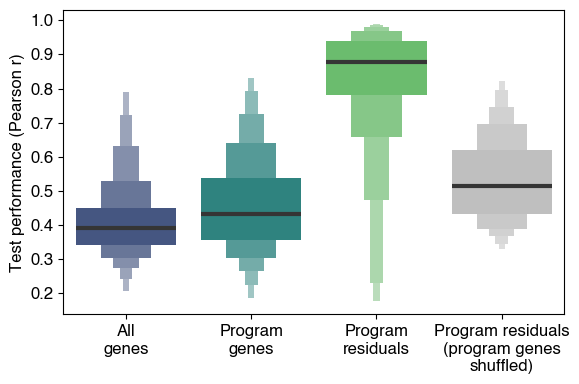

In [15]:
plt.figure(figsize=(6,4))
sns.boxenplot(df_plot, x = 'category', y = 'corr', k_depth = 5, showfliers = False, edgecolor = 'none', width_method = 'exponential', hue = 'category', palette = sns.color_palette('viridis', 3).as_hex() + ['#bfbfbf'], line_kws = {'linewidth': 3})
plt.ylabel("Test performance (Pearson r)")
plt.xlabel("")
plt.tight_layout()
plt.savefig("plots/6c_performance_violins.pdf")
plt.show()

In [11]:
from scipy.stats import mannwhitneyu
mannwhitneyu(df_plot[df_plot.category == 'Program\ngenes']['corr'], df_plot[(df_plot.category == 'All\ngenes') & (df_plot.is_prgm == False)]['corr'], alternative = 'greater')

MannwhitneyuResult(statistic=np.float64(9685048.0), pvalue=np.float64(2.6297420176228604e-132))

In [17]:
df_plot.groupby('category').median()['corr']

/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/data1/normantm/eli/mamba/miniforge3/envs/scenv/lib/python3.11/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


category
All\ngenes                                      0.392354
Program\ngenes                                  0.431598
Program\nresiduals                              0.877998
Program residuals\n(program genes\nshuffled)    0.515457
Name: corr, dtype: float64

### 6d cis-chromatin uplift by neomorphic score

In [4]:
from sklearn.metrics import r2_score
df_ids = test_preds.query("not is_single").groupby('guide_target').apply(lambda g: np.corrcoef(g.resid, g.pred_resid)[0, 1]).to_frame('real_corr')
df_ids['real_r2'] = test_preds.query("not is_single").groupby('guide_target').apply(lambda g: r2_score(g.resid, g.pred_resid)).to_frame('real_r2')
df_ids['shuffled_r2'] = test_preds.query("not is_single").groupby('guide_target').apply(lambda g: r2_score(g.resid, g.peak_ablated_pred_resid)).to_frame('real_r2')
df_ids = df_ids.join(test_preds.query("not is_single").groupby('guide_target').apply(lambda g: np.corrcoef(g.resid, g.peak_ablated_pred_resid)[0, 1]).to_frame('shuffled_corr'))
df_ids['atac_uplift'] = df_ids.real_corr - df_ids.shuffled_corr
df_ids['atac_uplift_pct'] = 100 * (df_ids.atac_uplift / df_ids.shuffled_corr)
df_ids['atac_uplift_r2'] = df_ids.real_r2 - df_ids.shuffled_r2

/tmp/ipykernel_684895/4035854652.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ids = test_preds.query("not is_single").groupby('guide_target').apply(lambda g: np.corrcoef(g.resid, g.pred_resid)[0, 1]).to_frame('real_corr')
/tmp/ipykernel_684895/4035854652.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_ids['real_r2'] = test_preds.query("not is_single").groupby('guide_target').apply(lambda g:

In [6]:
gex = sc.read("/data1/normantm/eli/T7/202511_RPE1_dg50/analysis/intermediate_files/251204_dg50_gex.h5ad")
geometry = pd.read_csv("/data1/normantm/eli/T7/rpe1_paper/intermediate_files/scvi_direct_global_interaction_metrics.csv", index_col=0)
ncells = gex.obs.guide_target.value_counts().to_frame('ncells').assign(log_ncells = np.log10(gex.obs.guide_target.value_counts()))
df_ids['atac_uplift'] = df_ids.real_corr - df_ids.shuffled_corr
df_ids = df_ids.join(ncells).join(geometry.r_neo)

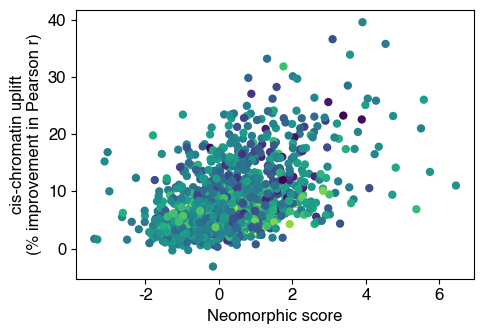

In [24]:
plt.figure(figsize = (5,3.5))
sns.scatterplot(df_ids, x = 'r_neo', y = 'atac_uplift_pct', hue = 'log_ncells', palette = 'viridis', legend = None, edgecolor = 'none')
plt.xlabel("Neomorphic score")
plt.ylabel("cis-chromatin uplift\n(% improvement in Pearson r)")
plt.tight_layout()
# plt.savefig('plots/6d_rneo_atac_uplift.pdf')
plt.show()

In [25]:
from scipy.stats import pearsonr, spearmanr
pearsonr(df_ids.atac_uplift_pct, df_ids.r_neo)

PearsonRResult(statistic=np.float64(0.4646657754397815), pvalue=np.float64(1.2388700543024812e-66))

2026-10-08 18:00:33 - INFO - maxp pruned
2026-10-08 18:00:33 - INFO - cmap pruned
2026-10-08 18:00:34 - INFO - post pruned
2026-10-08 18:00:34 - INFO - FFTM dropped
2026-10-08 18:00:34 - INFO - GPOS pruned
2026-10-08 18:00:34 - INFO - GSUB pruned
2026-10-08 18:00:34 - INFO - glyf pruned
2026-10-08 18:00:34 - INFO - Added gid0 to subset
2026-10-08 18:00:34 - INFO - Added first four glyphs to subset
2026-10-08 18:00:34 - INFO - Closing glyph list over 'GSUB': 32 glyphs before
2026-10-08 18:00:34 - INFO - Glyph names: ['.notdef', '.null', 'N', 'P', 'a', 'b', 'c', 'd', 'e', 'five', 'four', 'h', 'hyphen', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'r', 's', 'six', 'space', 't', 'two', 'uni0008', 'zero']
2026-10-08 18:00:34 - INFO - Glyph IDs:   [0, 1, 2, 3, 5, 10, 13, 14, 18, 21, 22, 23, 25, 26, 27, 51, 53, 70, 71, 72, 73, 74, 77, 78, 81, 82, 83, 84, 85, 87, 88, 89]
2026-10-08 18:00:34 - INFO - Closed glyph list over 'GSUB': 32 glyphs afte

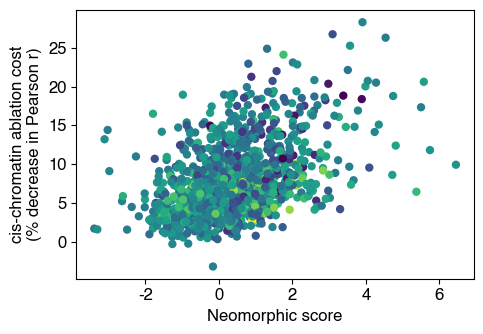

In [13]:
from scipy.stats import pearsonr

# cost = % of the intact model's Pearson r lost upon ablation
df_ids['ablation_cost_pct'] = 100 * (df_ids.real_corr - df_ids.shuffled_corr) / df_ids.real_corr

plot_df = df_ids.dropna(subset=['r_neo', 'ablation_cost_pct'])

plt.figure(figsize=(5, 3.5))
sns.scatterplot(plot_df, x='r_neo', y='ablation_cost_pct', hue='log_ncells',
                palette='viridis', legend=None, edgecolor='none')
plt.xlabel("Neomorphic score")
plt.ylabel("cis-chromatin ablation cost\n(% decrease in Pearson r)")
plt.tight_layout()
plt.savefig('/data1/normantm/eli/T7/rpe1_paper/plots/6d_rneo_ablation_cost.pdf')
plt.show()

In [14]:
pearsonr(plot_df.r_neo, plot_df.ablation_cost_pct)

PearsonRResult(statistic=np.float64(0.46573912871413375), pvalue=np.float64(5.66983177182448e-67))